## PET VAE Model Training Script
##
## This notebook trains a Variational Autoencoder (VAE) for PET image reconstruction.
## Model architecture is defined in petVAE_model_architecture.ipynb
##
## Main workflow:
## 1. Load and preprocess metadata
## 2. Create train/validation/test splits
## 3. Initialize model and optimizer
## 4. Train model with early stopping
## 5. Save best model checkpoint
#


In [ ]:
import numpy as np
import torch
from torch import nn, optim
from torch.nn import functional as F
import pandas as pd
import matplotlib.pyplot as plt
import nibabel as nib

from torch.utils.data import Dataset, DataLoader

import re
import os, fnmatch

import nibabel as nib

In [ ]:
print(torch.version.cuda)

11.7


In [ ]:
print('library uploaded, I am starting')

library uploaded, I am starting


In [ ]:
from addl_models_bimodel_pytorch import VAE1_2, VAE_multimodel,VAE_1modality_PET

[NbConvertApp] Converting notebook addl_models_bimodel_pytorch.ipynb to script
[NbConvertApp] Writing 48447 bytes to addl_models_bimodel_pytorch.py


In [ ]:

date = '26_05_25'
path = '/csc/epitkane/home/atagmazi/ADDL_pipeline/scripts/bimodal_VAE/' + date

In [ ]:
# Load metadata containing paths to PET and MRI image files
# Metadata includes image paths, normalization statistics, and other preprocessing information
meta = pd.read_csv('/csc/epitkane/home/atagmazi/ADDL_pipeline/scripts/pet_mri_pairs.csv',header=[0], index_col=[0])
meta.reset_index(drop=True, inplace = True)
meta = meta.iloc[:,1:]  # Remove first column (likely index column)

In [ ]:
# DATA CLEANING: Remove empty scans (scans with pet_max = 0)
# These are likely failed preprocessing or empty image files
# why after quality control there is still empty scans? remove them 
meta = meta[meta.pet_max>0]

In [ ]:
# Prep brain mask
brain_mask = nib.load('/csc/epitkane/home/atagmazi/tpl-MNI152NLin6Asym_res-01_desc-brain_T1w.nii.gz').get_fdata()
brain_mask[brain_mask != 0] = 1
#brain_mask = np.stack([brain_mask] * 2, axis=-1)

(-0.5, 217.5, 181.5, -0.5)

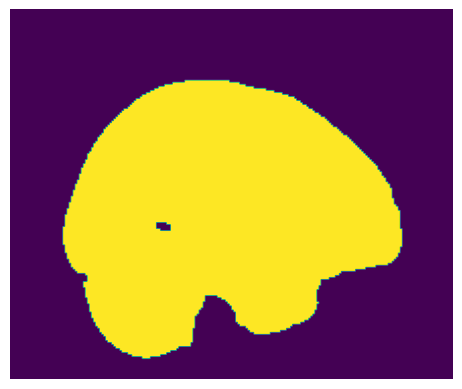

In [ ]:
'''plt.imshow(np.rot90(brain_mask[60,:,:]))
plt.axis('off')'''

In [ ]:
#meta2 = meta[meta['MRI_Imaging.protocol'] == 'SIEMENS'].copy()
#meta2.reset_index(drop=True, inplace = True)
meta2 = meta.copy()
meta2.to_csv(path + '/metafile_shuffled_'+ date+'.csv')


In [ ]:
meta2.shape

(942, 39)

In [ ]:
stat = np.load("/csc/epitkane/home/atagmazi/ADDL_pipeline/scripts/stats_train.npz")
p_quant90 = stat['p_quant90']
m_quant90 = stat['m_quant90']

p_quant95 = stat['p_quant95']
m_quant95 = stat['m_quant95']

p_quant99 = stat['p_quant99']
m_quant99 = stat['m_quant99']

p_quant999 = stat['p_quant999']
m_quant999 = stat['m_quant999']

p_std = stat['p_std']
m_std = stat['m_std']

p_mean_clip = stat['p_mean_clip']
m_mean_clip = stat['m_mean_clip']
p_std_clip = stat['p_std_clip']
m_std_clip = stat['m_std_clip']

p_min_clip = stat['p_mim_clip']
m_min_clip = stat['m_min_clip']
p_max_clip = stat['p_max_clip']
m_max_clip = stat['m_max_clip']

In [ ]:
stat['p_quant99']

array(2.1990006)

In [ ]:
stat['p_std_clip']

array(0.60700436)

In [ ]:
#split data on train and test subsets
train_size = 0.8
train_end = int(len(meta2)*train_size)

In [ ]:
data_train = meta2[:train_end]
data_test = meta2[train_end:]

In [ ]:
# DATA PARTITIONING: Split data into train/validation/test sets

# Split structure:
# - Train: First 80% of train set (64% of total data)
# - Validation: Last 20% of train set (16% of total data)  
# - Test: Remaining 20% of total data
#
data_partition = dict()

# Split train set further into train (80%) and validation (20%)
t = int(0.8*np.shape(data_train)[0])  # 80% of train set
v = int(0.2*np.shape(data_train)[0])   # 20% of train set (not used, calculated for reference)

# Create partitions using sequential indexing
# WARNING: Sequential split without shuffle can cause data leakage
data_partition['train'] = meta2.loc[:t,:].reset_index(drop=True)  # First 80% of train set
data_partition['validation'] = meta2.loc[t+1:train_end,:].reset_index(drop=True)  # Last 20% of train set
data_partition['test'] = meta2.loc[train_end+1:,:].reset_index(drop=True)  # Test set (20% of total)

data_partition['all'] = meta2.loc[:,:].reset_index(drop=True) #!!


In [ ]:
# augmentation function
def aug_random(scan):
    # add different level of noise
    def aug_noise0(scan):
        t1_noise = add_gaussian_noise(scan.copy(), sigma=0)
        return t1_noise
    def aug_noise5(scan):
        t1_noise = add_gaussian_noise(scan.copy(), sigma=0.05)
        return t1_noise
    def aug_noise10(scan):
        t1_noise = add_gaussian_noise(scan.copy(), sigma=0.1)
        return t1_noise
    def aug_noise15(scan):
        t1_noise = add_gaussian_noise(scan.copy(), sigma=0.15)
        return t1_noise
    def aug_noise20(scan):
        t1_noise = add_gaussian_noise(scan.copy(), sigma=0.2)
        return t1_noise
    def aug_noise25(scan):
        t1_noise = add_gaussian_noise(scan.copy(), sigma=0.25)
        return t1_noise
    # flip an image
    def aug_flipx(scan):# 0 - flip by x axis, 1 - y axis,2 - by z, but it's seems useless
        t1_flip = flip(scan.copy(), axis=0)
        return t1_flip
    def aug_flipy(scan):
        t1_flip = flip(scan.copy(), axis=1)
        return t1_flip
    fns = [aug_noise0,aug_noise5,aug_noise10,aug_noise15,aug_noise20,aug_noise25,aug_flipx,aug_flipy]
    return choice(fns)(scan)

In [ ]:
#p_quant99 = np.quantile(meta2.pet_max, 0.99)
#m_quant99 = np.quantile(meta2.mri_max, 0.99)

In [ ]:
class PETMRISliceDataset(Dataset):
    """
    PyTorch Dataset for 2D slices extracted from PET scans.
    
    This dataset extracts 2D slices from 3D PET volumes along a specified axis (sagittal, coronal, or axial).
    Each 3D volume is split into multiple 2D slices, which are then normalized and returned.
    
    
    Parameters:
    - list_IDs_pet: List of file paths to PET scan files (.nii or .nii.gz)
    - slice_axis: Axis along which to extract slices (0=sagittal, 1=coronal, 2=axial, default=2)
    - brain_mask: Binary mask to apply to slices (optional)
    - pet_minimum/maximum: Min/max values for normalization (from training statistics)
    - pet_quant: Quantile threshold for clipping (default: 99.9th percentile)
    - sagittal_dim/coronal_dim/axial_dim: Dimensions of input volumes
    """
    def __init__(self, list_IDs_pet, slice_axis=2, brain_mask=None, 
                 pet_minimum= p_min_clip, pet_maximum=p_max_clip,
                 mri_minimum= m_min_clip, mri_maximum=m_max_clip,
                 pet_quant = p_quant999,mri_quant = m_quant999, 
                 pet_mean = p_mean_clip,mri_mean = m_mean_clip,
                 pet_std = p_std_clip,mri_std = m_std_clip,
                 sagittal_dim=182, coronal_dim=218, axial_dim=182):
        self.list_IDs_pet = list_IDs_pet
        #self.list_IDs_mri = list_IDs_mri
        self.slice_axis = slice_axis  # 0 = sagittal, 1 = coronal, 2 = axial
        self.brain_mask = brain_mask
        
        self.pet_minimum = pet_minimum
        self.pet_maximum = pet_maximum
        self.pet_quant = pet_quant
        self.pet_mean = pet_mean
        self.pet_std = pet_std
        self.mri_minimum = mri_minimum
        self.mri_maximum = mri_maximum
        self.mri_quant = mri_quant
        self.mri_mean = mri_mean
        self.mri_std = mri_std
        
        self.sagittal_dim = sagittal_dim
        self.coronal_dim = coronal_dim
        self.axial_dim = axial_dim
        self.slices = self.load_all_slices()  # Preload slice paths
        self.indices = list(range(len(self.slices)))

    def load_all_slices(self):
        """Extracts and pairs 2D slices from all PET/MRI scans."""
        slices = []
        slice_id = 0
        for pet_path in zip(self.list_IDs_pet):
            if self.slice_axis == 0:  # Sagittal
                num_slices = slice_id + self.sagittal_dim 
            elif self.slice_axis == 1:  # Coronal
                num_slices = slice_id + self.coronal_dim 
            else:  # Axial (default)
                num_slices = slice_id + self.axial_dim 

            for within_img_num, i in enumerate(range(slice_id, num_slices)):
                slices.append((pet_path, i, within_img_num))  # Store slice index
            slice_id = num_slices
        return slices

    def __len__(self):
        """Returns the number of slices."""
        return len(self.slices)

    def __data_generation(self, batch_slices):
        """Generates one batch of 2D slices."""
        pet_slices = []
        pet_ids = []
        batch_data = []

        #pet_path, slice_idx, slice_num_inimg = batch_slices[0]
        for slice_info in batch_slices:
            pet_path, slice_idx, slice_num_inimg = slice_info  # Ensure correct unpacking
            pet_path = pet_path[0]
            if not isinstance(pet_path, str):  
                print(pet_path)
                print(slice_idx)
                print(slice_num_inimg)
                raise ValueError(f"Expected pet_path to be a string, got {type(pet_path)}")
                
        
        img_pet = nib.load(pet_path).get_fdata()
        

        # Extract the corresponding 2D slice
        if self.slice_axis == 0:  # Sagittal
            pet_slice = img_pet[slice_num_inimg, :, :]
            
            if self.brain_mask is not None:
                bm = self.brain_mask[slice_num_inimg, :, :]
                pet_slice *= bm
                
                    
        elif self.slice_axis == 1:  # Coronal
            pet_slice = img_pet[:, slice_num_inimg, :]
            
            if self.brain_mask is not None:
                bm = self.brain_mask[:, slice_num_inimg, :]
                pet_slice *= bm
                
            
        else:  # Axial (default)
            pet_slice = img_pet[:, :, slice_num_inimg]
            
            if self.brain_mask is not None:
                bm = self.brain_mask[:, :, slice_num_inimg]
                pet_slice *= bm
                

        # Skip slices with NaNs or empty regions
        #if np.isnan(pet_slice).any() and np.isnan(mri_slice).any():
        #    return None, None, None, None 
        #if np.max(pet_slice) == 0 and np.max(mri_slice) == 0:
        #    return None, None, None, None 
            # Skip empty slices
            #if pet_slice.size == 0 or mri_slice.size == 0:
            #    continue  # Skip this slice

        # Normalize if necessary (optional step, currently not applied)
        
        pet_norm = self.min_max_normalize(np.asarray(pet_slice, dtype=np.float32), float(self.pet_quant), self.pet_minimum, self.pet_maximum)
        
        pet_norm = np.clip(pet_norm, 1e-7, 1 - 1e-7) #???or just to 0 and 1?
        

        # Convert to NumPy arrays
        
        batch_data = np.array(pet_norm, dtype=np.float32)
        #print(batch_data.shape[0])
        batch_data = batch_data.reshape(1, batch_data.shape[0],  batch_data.shape[1])
        #print(batch_data.shape)
        #if len(batch_data) == 0:
            #return None, None, None
        

        # Convert to tensor
        return batch_data, pet_path, slice_num_inimg 

    def __getitem__(self, index):
        """Generates one slice of 2D images (per slice, not batch)."""
        # Get a single slice metadata
        pet_path, slice_idx, slice_num_inimg = self.slices[index]
        
        # Generate single slice data
        X, pet_ids, slice_n = self.__data_generation([(pet_path, slice_idx, slice_num_inimg)])
        X = torch.tensor(X, dtype=torch.float32)
        #print(X.shape)

        return { 'image': X, 'pet_ID': pet_ids, 'slice_number': slice_n }

    

    def quantile_norm(self, image, quantile, mean, std):
        image = np.asarray(image, dtype=np.float32).copy()  # Ensure array and prevent in-place modification
        #image = np.clip(image, 0, quantile)  # Clip values above quantile
        #image = (image - mean) / (std + 1e-8)  # Avoid division by zero
        return image
    def min_max_normalize(self,image,quantile, min_val, max_val):
        image = np.asarray(image, dtype=np.float32).copy()  # Ensure array and prevent in-place modification
        image = np.clip(image, 0, quantile)  # Clip values above quantile
        return (image - min_val) / (max_val - min_val + 1e-8)  # Avoid division by zero


In [ ]:
# creating datasets 
train_dataset = PETMRISliceDataset(list_IDs_pet = data_partition['train']['PET_PATH_normalised'], brain_mask = brain_mask)

validation_dataset = PETMRISliceDataset(list_IDs_pet = data_partition['validation']['PET_PATH_normalised'], brain_mask = brain_mask)

test_dataset = PETMRISliceDataset(list_IDs_pet = data_partition['test']['PET_PATH_normalised'], brain_mask = brain_mask)


In [ ]:
# Creating DataLoaders for training, validation, and testing
# Batch size: 64 slices per batch
# num_workers: 8 parallel workers for data loading
#
train_dataloader = DataLoader(train_dataset, batch_size=64,
                        shuffle=False, num_workers=8)

validation_dataloader = DataLoader(validation_dataset, batch_size=64,
                        shuffle=False, num_workers=8)

test_dataloader = DataLoader(test_dataset, batch_size=64,
                        shuffle=False, num_workers=8)

In [ ]:
train_dataset[0]['image'].shape

torch.Size([1, 182, 218])

In [ ]:
train_dataset[0]['image'].max()

tensor(0.)

In [ ]:
len(validation_dataloader.dataset) # number of slices

100282

In [ ]:
len(validation_dataloader) # number of batches

1567

In [ ]:
#plt.hist(data[:,0,:,:].flatten())

In [ ]:
1e-5

1e-05

In [ ]:
# MODEL INITIALIZATION AND TRAINING SETUP
# 
# Model: VAE_1modality_PET - Single-modality VAE for PET images
# - feature_size: 64*64*64 = 262144 (size after encoder flattening)
# - latent_size: 64 (dimension of latent space)
# - in_channels: 1 (single channel for PET)
#
# Optimizer: Adam with learning rate 1e-5
# Scheduler: ReduceLROnPlateau - reduces learning rate when validation loss plateaus
#   - patience: 5 epochs
#   - factor: 0.1 (reduce LR by 10x)
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")

model = VAE_1modality_PET(64*64*64, latent_size =64,in_channels=1).to(device)

optimizer = optim.Adam(model.parameters(), lr=1e-5)
# Alternative optimizers (not used):
#optimizer = optim.SGD(model.parameters(), lr=1e-7)
#optimizer = adamod.AdaMod(model.parameters(), lr=1e-5, beta3=0.999)

scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, 'min', patience=5, factor=0.1)

In [ ]:
sum([param.nelement() for param in model.parameters()])

78953258

In [ ]:
# LOSS FUNCTION: VAE loss = Reconstruction Loss + KL Divergence Loss
#
# Total Loss = MSE(reconstruction, input) + beta * KL(q(z|x) || p(z))
#
# - Reconstruction Loss: MSE between reconstructed and input images
# - KL Divergence Loss: Regularization term to ensure latent distribution is close to N(0,1)
# - beta: Weight for KL term (currently hardcoded to 0.00001, very small)
#
# NOTE: beta parameter is 0.00001,this means KL divergence has minimal impact on training

def loss_function(recon_x, x, mu, logvar, beta):
    """
    Computes VAE loss: reconstruction loss + KL divergence.
    
    Parameters:
    - recon_x: Reconstructed images
    - x: Input images
    - mu: Mean of latent distribution
    - logvar: Log-variance of latent distribution
    - beta: KL divergence weight (currently not used, hardcoded to 0.00001)
    
    Returns:
    - recon_loss: Mean squared error between reconstruction and input
    - kld_loss: KL divergence loss (mean across batch)
    """
    # Reconstruction loss: Mean Squared Error
    # Alternative losses (not used):
    #recon_loss = F.binary_cross_entropy(recon_x, x, reduction='mean')
    #recon_loss = torch.mean(torch.mean((x - recon_x) ** 2, dim=(1, 2, 3)))
    recon_loss = F.mse_loss(recon_x, x, reduction='mean')
    
    # KL Divergence Loss: Regularization term
    # Clamp logvar to prevent numerical instability
    logvar = torch.clamp(logvar, max=5, min=-5)
    
    # KL divergence formula: -0.5 * sum(1 + logvar - mu^2 - exp(logvar))
    # NOTE: beta parameter is ignored, using hardcoded 0.00001
    # This makes KL divergence very small, effectively training an autoencoder rather than VAE
    KLD = -0.00001 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp(), dim=1)
    
    # Alternative KL formulations (not used):
    #KLD = -1 * beta * torch.sum(1 + logvar - mu.pow(2) - logvar.exp(), dim=1)
    #KLD = 0 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp())  # No KL regularization
    
    return recon_loss, torch.mean(KLD)
   


In [ ]:
# BETA SCHEDULING FUNCTIONS: Control KL divergence weight during training
#
# These functions implement beta warm-up strategies for VAE training:
# - Linear warm-up: Gradually increase beta from 0 to max_beta
# - Cyclic warm-up: Cycle beta value periodically
#
# NOTE: Currently, cyclic_beta_schedule is used but beta is hardcoded in loss_function
#       These functions are defined but their output is not actually used
def beta_schedule(epoch, total_epochs, max_beta=0.1):
    """
    Linear beta warm-up: beta increases linearly from 0 to max_beta over total_epochs.
    """
    return max_beta * (epoch / total_epochs)

def cyclic_beta_schedule(epoch, cycle_length=50, max_beta=0.001):
    """
    Cyclic beta schedule: beta cycles from 0 to max_beta every cycle_length epochs.
    Currently used in training but output is ignored (beta hardcoded in loss_function).
    """
    cycle_pos = epoch % cycle_length
    return max_beta * (cycle_pos / (cycle_length - 1))

In [ ]:
# TRAINING CONFIGURATION
total_epochs = 1000  # Maximum number of training epochs
# Early stopping is implemented in the training loop (Cell 68) with patience=10

def train(epoch):
    """
    Training function for one epoch.
    
    Process:
    1. Set model to training mode
    2. Iterate through training batches
    3. Forward pass: encode -> sample -> decode
    4. Compute loss (reconstruction + KL divergence)
    5. Backpropagate and update weights
    
    Returns:
    - train_loss: Average loss for the epoch
    """
    #device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
    model.train()  # Set model to training mode (enables dropout, batch norm updates, etc.)
    train_loss = 0
    
    for batch_idx, (data) in enumerate(train_dataloader):
        # Extract image tensor and move to device (GPU if available)
        data = data['image'].type(torch.FloatTensor).to(device)
        
        # Zero gradients from previous iteration
        optimizer.zero_grad()
        
        # Forward pass: encode -> reparameterize -> decode
        recon_batch, mu, logvar = model(data)
        
        # Compute beta schedule (output is computed but not used - beta is hardcoded in loss_function)
        #beta = beta_schedule(epoch, total_epochs)  # Linear schedule (not used)
        beta = cyclic_beta_schedule(epoch)  # Cyclic schedule (computed but ignored)
        
        # Compute loss: reconstruction + KL divergence
        recon, kld = loss_function(recon_batch, data, mu, logvar, beta)
        loss = recon + kld
        
        #print("Mean mu:", mu.mean().item(), "Min:", mu.min().item(), "Max:", mu.max().item())

        #torch.save(mean, path+'/mu')
        #torch.save(var, path+'/logvar')
        #torch.save(data, path+'/x')
        #torch.save(recon_batch, path+'/recon_batch')
        #torch.save(recon_l, path+'/recon_loss')
        #print(logvar)
        #print(torch.max(logvar))
        #print(torch.min(logvar))
        #logvar = torch.clamp(logvar, max = 10.0) # limitation on logvar value ???
        
        #print(kld)
        #print(recon)
        #loss = loss_function(recon_batch, data, mu, logvar)
        loss.backward()
        #print(f"Allocated memory: {torch.cuda.memory_allocated() / (1024**3):.2f} GB")
        #print(f"Reserved memory: {torch.cuda.memory_reserved() / (1024**3):.2f} GB")
    
        #nn.utils.clip_grad_norm_(model.parameters(), 1.0) # gradient clipping to escape gradient exploding
        train_loss += loss.detach().cpu().numpy()
        optimizer.step()
        if batch_idx % 100 == 0:
            print('Train Epoch: {} [{}/{} ({:.0f}%)]\tTotal loss: {:.6f}\tReconstruction loss: {:.6f}  KL loss: {:.6f}'.format(
                epoch, batch_idx * len(data), len(train_dataloader.dataset),
                100. * batch_idx / len(train_dataloader),
                loss.sum().item() ,
            recon.sum().item() ,
            kld.sum().item() ))
            print(beta)
            #print("Mean logvar:", logvar.mean().item(), "Min:", logvar.min().item(), "Max:", logvar.max().item())
    
            
        
        
    train_loss /= len(train_dataloader)
    print('====> Epoch: {} Average loss: {:.4f}'.format(
          epoch, train_loss))
    
    torch.cuda.empty_cache()
    return train_loss

In [ ]:
def validation(epoch):
    """
    Validation function for one epoch.
    
    Process:
    1. Set model to evaluation mode (disables dropout, batch norm uses running stats)
    2. Iterate through validation batches without gradient computation
    3. Compute loss and accumulate metrics
    
    Returns:
    - validation_loss: Average total loss for the epoch
    """
    model.eval()  # Set model to evaluation mode
    
    validation_loss = 0
    avg_reconstruction_loss = 0
    avg_kl_loss = 0
    total_reconstruction_loss = 0
    total_kl_loss = 0
    
    # Disable gradient computation for validation (saves memory and computation)
    with torch.no_grad():
        for i, (data) in enumerate(validation_dataloader):
            #cond = data['condition'].type(torch.FloatTensor).to(device)
            data = data['image'].type(torch.FloatTensor).to(device)
            
            recon_batch, mu, logvar = model(data) #, cond
            #beta = beta_schedule(epoch, total_epochs)
            beta = cyclic_beta_schedule(epoch)
            recon, kld = loss_function(recon_batch, data, mu, logvar,beta)
            loss = recon + kld
            validation_loss += loss.detach().item()
            total_reconstruction_loss += recon.detach().item()
            total_kl_loss += kld.detach().item()
            
            '''if i == 0:
                n = min(data.size(0), 5)
                comparison = torch.cat([data[:n],
                                      recon_batch.view(-1, 1, 28, 28)[:n]])
                save_image(comparison.cpu(),
                         'reconstruction_' + str(f"{epoch:02}") + '.png', nrow=n)'''

    validation_loss /= len(validation_dataloader)
    avg_reconstruction_loss = total_reconstruction_loss / len(validation_dataloader)
    avg_kl_loss = total_kl_loss / len(validation_dataloader)
    
    print('====> Validation total loss: {:.4f}\tReconstruction loss: {:.6f}  KL loss: {:.6f}'.format(validation_loss,avg_reconstruction_loss,avg_kl_loss))
    
    
    
    return validation_loss



In [ ]:
print('model training starts now')

In [ ]:
# MAIN TRAINING LOOP
# 
# Training configuration:
# - epochs: Maximum number of epochs (1000)
# - early_stop_thresh: Early stopping patience (10 epochs)
# - iterations: Maximum number of restart attempts if NaN/Inf occurs (5)
#
# Training process:
# 1. Train for one epoch
# 2. Validate on validation set
# 3. Save model if validation loss improves
# 4. Early stop if no improvement for early_stop_thresh epochs
# 5. Restart if NaN/Inf validation loss occurs (up to iterations times)
epochs = 1000
early_stop_thresh = 10  # Early stopping patience
best_epoch = 0
train_loss_list = []
val_loss_list = []
lr = []
i = 0
iterations = 5  # Maximum restart attempts if NaN/Inf occurs

while i < iterations:
    for epoch in range(0, epochs):

            train_loss = train(epoch)
            val_loss = validation(epoch)
            if np.isnan(val_loss) or np.isinf(val_loss):
                print('Validation loss - Nan, restart the loop :( ')
                i +=1
                break
                

            train_loss_list.append(train_loss)
            val_loss_list.append(val_loss)
            lr.append(optimizer.param_groups[0]["lr"])
            np.save(path + "/train_loss", np.array(train_loss_list))
            np.save(path +  "/val_loss", np.array(val_loss_list))
            np.save(path +  "/lr", np.array(lr))

            scheduler.step(val_loss) #!!!!!!!!!!!!!!!!!!!!

            if epoch == 0:
                best_loss = val_loss
                torch.save(model, path+"/best_model.pth")
            else:
                if val_loss < best_loss:
                    best_loss = val_loss
                    best_epoch = epoch
                    torch.save(model, path+"/best_model.pth")
                    #torch.save(model.state_dict(), path+"/best_model.pth")
                    #save_model(model, epoch)
                    #checkpoint(model, "best_model.pth")
                elif epoch - best_epoch >= early_stop_thresh:
                    i = iterations  # break while loop if model training was successful 
                    print("Early stopped training at epoch %d" % epoch)
                    break  # terminate the training loop
                    
    if epoch == epochs-1: # break while loop if model training was successful 
        break 


        

In [ ]:
print('Training is done!')